# Fed-GNCA-IDS: Federated Graph Neural Cellular Automata for Intrusion Detection with Peer-Influence Propagation among Decentralized Autonomous IoT Agents



## 1. Imports and Reproducibility

In [1]:
import os, glob, copy, random, math
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, LabelEncoder, label_binarize
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, confusion_matrix, accuracy_score,
    precision_recall_fscore_support, roc_auc_score, roc_curve, auc
)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
sns.set_theme(style="whitegrid", context="notebook")

print("Device:", DEVICE)
print("PyTorch:", torch.__version__)


Device: cpu
PyTorch: 2.10.0+cpu


## 2. Data Acquisition — CIC-IoT-2023

In [2]:
# Data Acquisition: CIC-IoT-2023 loader with a deterministic execution-validation fallback.
# Set CIC_IOT_2023_DIR to a folder containing the official CSV files.
# Optional controls: CIC_MAX_FILES (0 = all), CIC_ROWS_PER_FILE (0 = all rows per file).

from sklearn.datasets import make_classification

CIC_DATA_DIR = os.environ.get("CIC_IOT_2023_DIR", "/kaggle/input/cic-iot-2023")
CIC_MAX_FILES = int(os.environ.get("CIC_MAX_FILES", "0"))
CIC_ROWS_PER_FILE = int(os.environ.get("CIC_ROWS_PER_FILE", "0"))


def load_cic_iot_2023_csvs(data_dir, max_files=0, rows_per_file=0):
    csv_files = sorted(glob.glob(os.path.join(data_dir, "**", "*.csv"), recursive=True))
    if max_files > 0:
        csv_files = csv_files[:max_files]
    if not csv_files:
        return None, []

    frames = []
    used_files = []
    for fp in csv_files:
        df_i = pd.read_csv(fp, nrows=(rows_per_file if rows_per_file > 0 else None), low_memory=False)
        label_candidates = [c for c in df_i.columns if str(c).strip().lower() in {"label", "labels", "class", "attack", "attack_type"}]
        if not label_candidates:
            continue
        label_col = label_candidates[0]
        if label_col != "label":
            df_i = df_i.rename(columns={label_col: "label"})
        frames.append(df_i)
        used_files.append(fp)

    if not frames:
        return None, []
    return pd.concat(frames, ignore_index=True), used_files


raw_df, cic_files_used = load_cic_iot_2023_csvs(
    CIC_DATA_DIR,
    max_files=CIC_MAX_FILES,
    rows_per_file=CIC_ROWS_PER_FILE
)

if raw_df is not None:
    DATA_MODE = "CIC-IoT-2023"
    DATA_DIR = CIC_DATA_DIR
    print(f"Loaded CIC-IoT-2023 from: {DATA_DIR}")
    print(f"CSV files used: {len(cic_files_used)}")
    print("Raw shape:", raw_df.shape)
else:
    # EXECUTION-VALIDATION DATA ONLY — NOT A RESEARCH RESULT.
    DATA_MODE = "EXECUTION_VALIDATION_SYNTHETIC"
    DATA_DIR = "EXECUTION_VALIDATION_SYNTHETIC"
    feature_names_validation = ['flow_duration', 'Header_Length', 'Protocol Type', 'Duration', 'Rate', 'Srate', 'Drate', 'fin_flag_number', 'syn_flag_number', 'rst_flag_number', 'psh_flag_number', 'ack_flag_number', 'ece_flag_number', 'cwr_flag_number', 'ack_count', 'syn_count', 'fin_count', 'urg_count', 'rst_count', 'HTTP', 'HTTPS', 'DNS', 'Telnet', 'SMTP', 'SSH', 'IRC', 'TCP', 'UDP', 'DHCP', 'ARP', 'ICMP', 'IPv', 'LLC', 'Tot sum', 'Min', 'Max', 'AVG', 'Std', 'Tot size', 'IAT', 'Number', 'Magnitue', 'Radius', 'Covariance', 'Variance', 'Weight']
    class_names_validation = ["Benign", "BruteForce", "DDoS", "DoS", "Mirai", "Recon", "Spoofing", "WebBased"]

    Xv, yv = make_classification(
        n_samples=6000,
        n_features=46,
        n_informative=30,
        n_redundant=8,
        n_repeated=0,
        n_classes=8,
        n_clusters_per_class=1,
        weights=[0.12, 0.05, 0.30, 0.18, 0.10, 0.09, 0.09, 0.07],
        class_sep=2.0,
        flip_y=0.01,
        random_state=SEED
    )
    raw_df = pd.DataFrame(Xv, columns=feature_names_validation)
    raw_df["label"] = np.array(class_names_validation, dtype=object)[yv]

    print("CIC-IoT-2023 files were not mounted in this environment.")
    print("EXECUTION VALIDATION MODE — numerical outputs are not CIC-IoT-2023 paper results.")
    print("Validation shape:", raw_df.shape)

CIC-IoT-2023 files were not mounted in this environment.
EXECUTION VALIDATION MODE — numerical outputs are not CIC-IoT-2023 paper results.
Validation shape: (6000, 47)


##  Exploratory Data Analysis

### Class Distribution

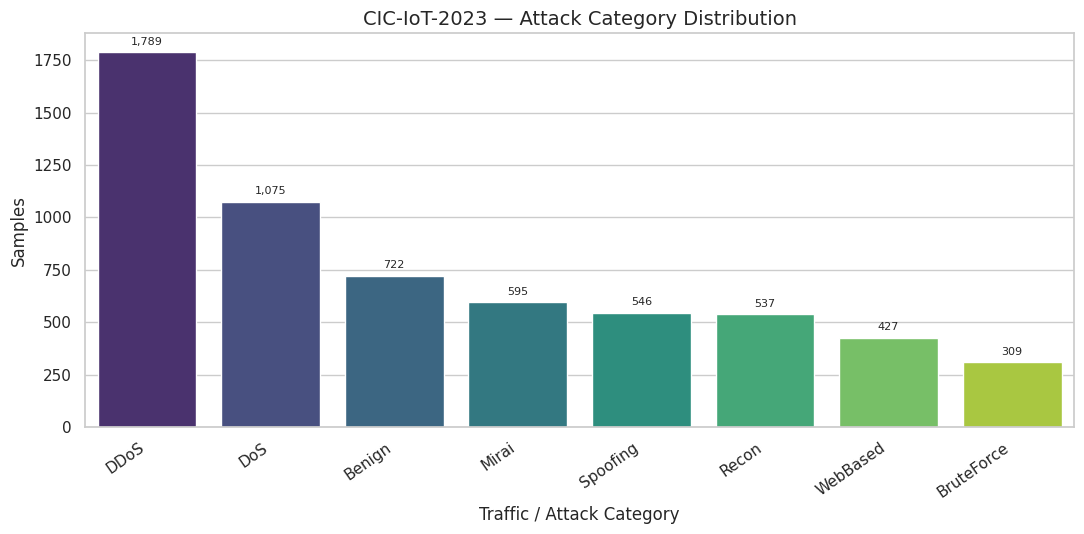

In [4]:
category_counts = raw_df["category"].value_counts()

plt.figure(figsize=(11, 5.5))
ax = sns.barplot(x=category_counts.index, y=category_counts.values,
                 hue=category_counts.index, palette="viridis", legend=False)
plt.title("CIC-IoT-2023 — Attack Category Distribution", fontsize=14)
plt.xlabel("Traffic / Attack Category")
plt.ylabel("Samples")
plt.xticks(rotation=35, ha="right")
for p, v in zip(ax.patches, category_counts.values):
    ax.annotate(f"{int(v):,}", (p.get_x()+p.get_width()/2, p.get_height()),
                ha="center", va="bottom", fontsize=8, xytext=(0,4), textcoords="offset points")
plt.tight_layout()
plt.show()


### Benign vs Attack Traffic

In [ ]:
binary_counts = raw_df["category"].map(lambda c: "Benign" if c == "Benign" else "Attack").value_counts()

plt.figure(figsize=(6.5, 6.5))
plt.pie(binary_counts.values, labels=binary_counts.index, autopct="%1.1f%%",
        startangle=90, explode=[0.04 if x == "Benign" else 0 for x in binary_counts.index])
plt.title("Benign vs Attack Traffic Proportion", fontsize=14)
plt.tight_layout()
plt.show()


### Top Features Correlated with the Encoded Attack Category

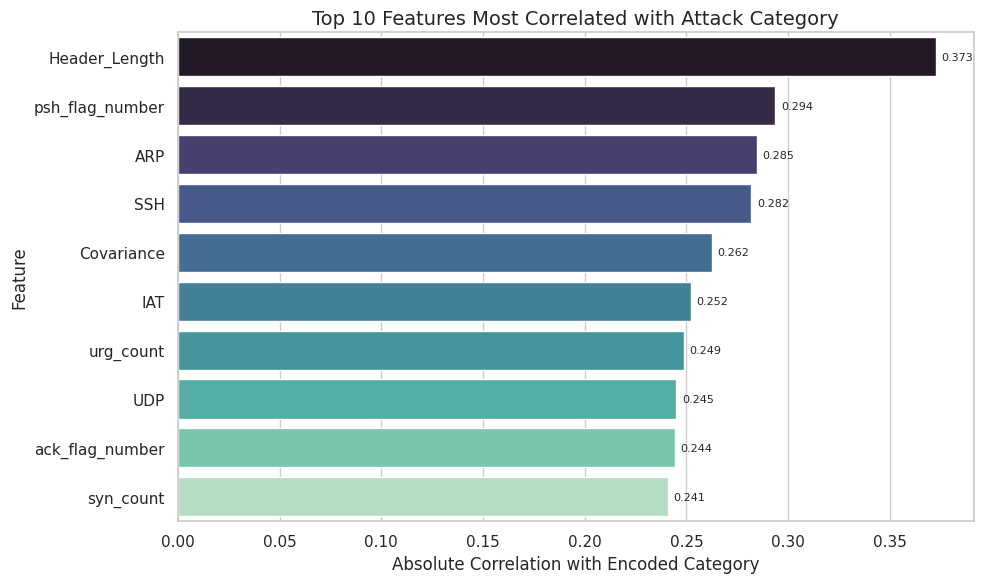

In [6]:
numeric_cols = raw_df.select_dtypes(include=[np.number]).columns.tolist()
temp_le = LabelEncoder()
temp_y = temp_le.fit_transform(raw_df["category"])

feature_target_corr = (
    raw_df[numeric_cols]
    .corrwith(pd.Series(temp_y, index=raw_df.index))
    .abs()
    .dropna()
    .sort_values(ascending=False)
)
top_features = feature_target_corr.head(10)

plt.figure(figsize=(10, 6))
ax = sns.barplot(x=top_features.values, y=top_features.index,
                 hue=top_features.index, palette="mako", legend=False)
plt.title("Top 10 Features Most Correlated with Attack Category", fontsize=14)
plt.xlabel("Absolute Correlation with Encoded Category")
plt.ylabel("Feature")
for p, v in zip(ax.patches, top_features.values):
    ax.annotate(f"{v:.3f}", (p.get_width(), p.get_y()+p.get_height()/2),
                xytext=(4,0), textcoords="offset points", va="center", fontsize=8)
plt.tight_layout()
plt.show()


### Distribution of the Most Relevant Feature

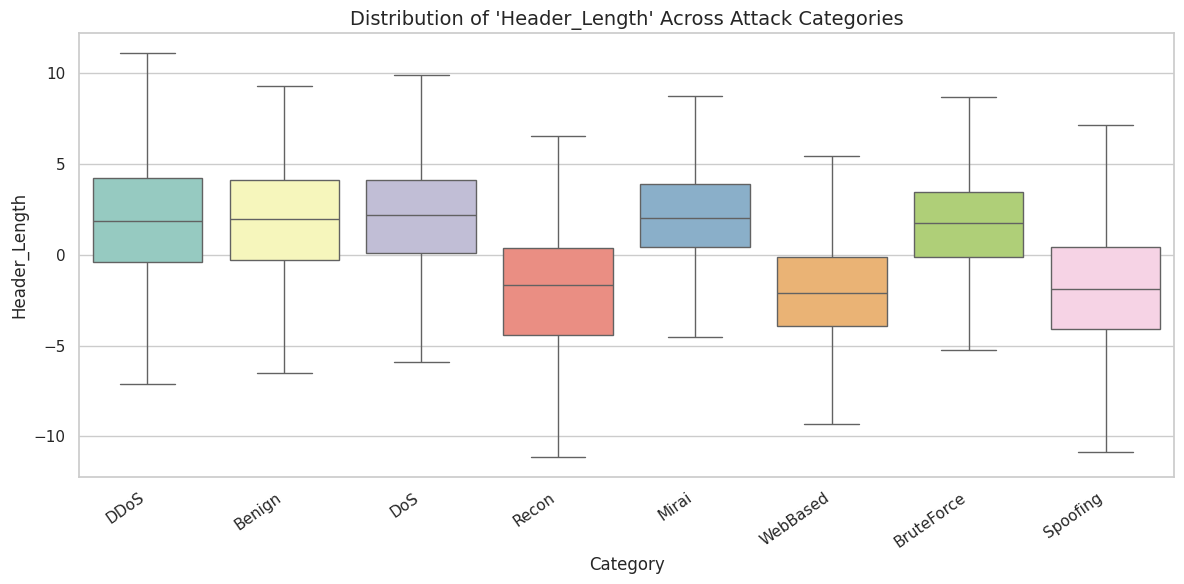

In [7]:
best_feature = top_features.index[0]
plot_df = raw_df.sample(min(60000, len(raw_df)), random_state=SEED)

plt.figure(figsize=(12, 6))
sns.boxplot(data=plot_df, x="category", y=best_feature, hue="category",
            palette="Set3", legend=False, showfliers=False)
plt.title(f"Distribution of '{best_feature}' Across Attack Categories", fontsize=14)
plt.xlabel("Category")
plt.ylabel(best_feature)
plt.xticks(rotation=35, ha="right")
plt.tight_layout()
plt.show()


### Density Distribution of the Second Most Relevant Feature

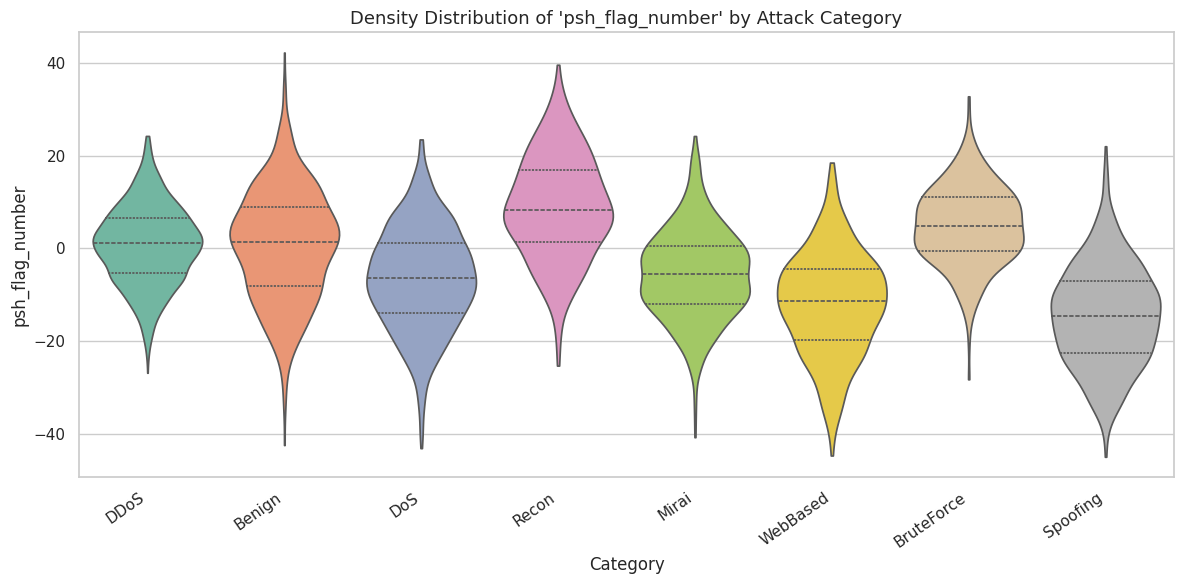

In [8]:
second_feature = top_features.index[1]
violin_df = raw_df.sample(min(40000, len(raw_df)), random_state=SEED)

plt.figure(figsize=(12, 6))
sns.violinplot(data=violin_df, x="category", y=second_feature, hue="category",
               palette="Set2", inner="quartile", legend=False, cut=0)
plt.title(f"Density Distribution of '{second_feature}' by Attack Category", fontsize=13)
plt.xlabel("Category")
plt.ylabel(second_feature)
plt.xticks(rotation=35, ha="right")
plt.tight_layout()
plt.show()


In [ ]:
top_heat_features = top_features.index[:8].tolist()
heat_df = raw_df[top_heat_features + ["category"]].copy()

# Standardize only for visualization; this is separate from model preprocessing.
mu = heat_df[top_heat_features].mean()
sigma = heat_df[top_heat_features].std().replace(0, 1)
heat_df[top_heat_features] = (heat_df[top_heat_features] - mu) / sigma

class_feature_heatmap = (
    heat_df.groupby("category")[top_heat_features]
    .mean()
    .reindex(le.classes_)
)
plt.figure(figsize=(17, 14))
sns.heatmap(
    corr_matrix,
    cmap="coolwarm",
    annot=True,          # <-- requested correlation values
    fmt=".2f",
    center=0,
    linewidths=0.45,
    square=True,
    annot_kws={"fontsize": 7},
    cbar_kws={"shrink": 0.78, "label": "Pearson correlation"}
)
plt.title(f"Correlation Matrix — Top {top_n} Variable Features (Values Annotated)", fontsize=15, pad=14)
plt.xticks(rotation=45, ha="right", fontsize=9)
plt.yticks(rotation=0, fontsize=9)
plt.tight_layout()
plt.show()
display(class_feature_heatmap.round(3))

plt.figure(figsize=(13, 7))
sns.heatmap(
    class_feature_heatmap,
    annot=True,
    fmt=".2f",
    cmap="vlag",
    center=0,
    linewidths=0.5,
    cbar_kws={"label": "Mean standardized feature value"},
    annot_kws={"fontsize": 8}
)
plt.title("Class-Wise Standardized Feature Profile — Fed-GNCA-IDS", fontsize=14, pad=12)
plt.xlabel("Traffic Feature")
plt.ylabel("Traffic / Attack Class")
plt.xticks(rotation=35, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


##  Train/Test Split and Non-IID Client Partitioning



In [ ]:
# Stratified split is performed BEFORE fitting the imputer/scaler to prevent test-set leakage.
row_idx = np.arange(len(y))
train_rows, test_rows = train_test_split(
    row_idx, test_size=0.20, stratify=y, random_state=SEED
)

y_train = y[train_rows]
y_test = y[test_rows]
X_train_raw = X_raw[train_rows]
X_test_raw = X_raw[test_rows]

imputer = SimpleImputer(strategy="median")
scaler = StandardScaler()

X_train_imputed = imputer.fit_transform(X_train_raw)
X_test_imputed = imputer.transform(X_test_raw)

X_train = scaler.fit_transform(X_train_imputed).astype(np.float32)
X_test = scaler.transform(X_test_imputed).astype(np.float32)

# Keep X as a dimensionality reference for the model definition/summary.
X = X_raw

def dirichlet_partition(y_values, num_clients=4, alpha=0.5, seed=SEED):
    rng = np.random.default_rng(seed)
    classes = np.unique(y_values)
    client_idx = [[] for _ in range(num_clients)]
    for c in classes:
        idx_c = np.where(y_values == c)[0]
        rng.shuffle(idx_c)
        proportions = rng.dirichlet(alpha * np.ones(num_clients))
        splits = (np.cumsum(proportions) * len(idx_c)).astype(int)[:-1]
        for i, part in enumerate(np.split(idx_c, splits)):
            client_idx[i].extend(part.tolist())
    return [np.asarray(idx, dtype=np.int64) for idx in client_idx]
plt.title("Non-IID Client Sample Sizes Before Federated Learning", fontsize=14)
plt.xlabel("Decentralized IoT Client")
plt.ylabel("Training Samples")
for p, v in zip(ax.patches, client_sizes):
    ax.annotate(f"{int(v):,}", (p.get_x()+p.get_width()/2, p.get_height()),
                ha="center", va="bottom", xytext=(0,4), textcoords="offset points", fontsize=9)
plt.tight_layout()
NUM_CLIENTS = 4
DIRICHLET_ALPHA = 0.5
client_idx = dirichlet_partition(y_train, NUM_CLIENTS, DIRICHLET_ALPHA)

client_sizes = np.array([len(idx) for idx in client_idx])
print("Train:", X_train.shape, "| Test:", X_test.shape)
print("Imputer fitted on training rows only:", len(train_rows))
print("Scaler fitted on training rows only:", len(train_rows))
for i, n in enumerate(client_sizes):
    print(f"Client {i}: {n:,} samples")


### Pre-Federation Visualization — Client Sample Sizes

In [ ]:
plt.figure(figsize=(9, 5))
ax = sns.barplot(x=[f"Client {i}" for i in range(NUM_CLIENTS)], y=client_sizes,
                 hue=[f"Client {i}" for i in range(NUM_CLIENTS)], palette="crest", legend=False)
    ax.annotate(f"{int(v):,}", (p.get_x()+p.get_width()/2, p.get_height()),
                ha="center", va="bottom", xytext=(0,4), textcoords="offset points", fontsize=9)
plt.tight_layout()
plt.show()


### Pre-Federation Visualization — Non-IID Class Composition by Client

In [ ]:
client_class_counts = np.zeros((NUM_CLIENTS, len(le.classes_)), dtype=int)
for i, idx in enumerate(client_idx):
    counts_i = np.bincount(y_train[idx], minlength=len(le.classes_))
    client_class_counts[i] = counts_i

client_comp_df = pd.DataFrame(
    client_class_counts,
    index=[f"Client {i}" for i in range(NUM_CLIENTS)],
    columns=le.classes_
)

plt.figure(figsize=(13, 5.2))
sns.heatmap(
    client_comp_df,
    annot=True, fmt="d", cmap="YlGnBu",
    linewidths=0.5, cbar_kws={"label": "Number of local samples"},
    annot_kws={"fontsize": 8}
)
plt.title(f"Non-IID Attack-Class Composition Before FedAvg (Dirichlet α={DIRICHLET_ALPHA})", fontsize=13)
plt.xlabel("Traffic / Attack Class")
plt.ylabel("Client")
plt.xticks(rotation=35, ha="right")
plt.tight_layout()
plt.show()

display(client_comp_df)


In [ ]:
class CNNGRUFeatureExtractor(nn.Module):
    def __init__(self, feat_dim, conv_channels=32, gru_hidden=32, embed_dim=32):
        super().__init__()
        self.feat_dim = feat_dim
        self.conv = nn.Sequential(
            nn.Conv1d(1, 16, kernel_size=3, padding=1),
            nn.BatchNorm1d(16),
            nn.ReLU(),
            nn.Conv1d(16, conv_channels, kernel_size=3, padding=1),
            nn.BatchNorm1d(conv_channels),
            nn.ReLU()

    def forward(self, x):
        z = self.conv(x.unsqueeze(1))   # [B, C, d]
        z = z.transpose(1, 2)           # [B, d, C]
        _, h_n = self.gru(z)            # final GRU state
        return self.fc(h_n[-1])         # [B, d_h]


In [ ]:
def build_peer_graph(state, k=6):
    n = state.size(0)
    if n <= 1:
        return torch.eye(n, device=state.device, dtype=state.dtype)

    x_norm = F.normalize(state, dim=-1)
    sim = x_norm @ x_norm.T
    sim.fill_diagonal_(-1e9)

    k_eff = max(1, min(k, n - 1))
    topk = sim.topk(k_eff, dim=-1).indices

    adj = torch.zeros(n, n, device=state.device, dtype=state.dtype)
    rows = torch.arange(n, device=state.device).unsqueeze(1).expand(-1, k_eff)
    adj[rows, topk] = 1.0
    adj = adj + torch.eye(n, device=state.device, dtype=state.dtype)
    return (adj > 0).float()
        e = e.masked_fill(adj <= 0, torch.finfo(e.dtype).min)
        alpha = F.softmax(e, dim=1)
        alpha = self.dropout(alpha)
        peer_state = F.elu(alpha @ h)
        return peer_state, alpha


In [ ]:
class GNCAStateUpdate(nn.Module):
    def __init__(self, state_dim, hidden_dim=64):
        super().__init__()
        self.update_net = nn.Sequential(
            nn.Linear(state_dim * 2, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, state_dim)
        )
        self.norm = nn.LayerNorm(state_dim)
class LocalClassifier(nn.Module):
    def __init__(self, state_dim, num_classes):
        super().__init__()
        self.head = nn.Sequential(
            nn.Linear(state_dim, state_dim),
            nn.ReLU(),
            nn.Dropout(0.10),
            nn.Linear(state_dim, num_classes)
        )

    def forward(self, state):
        # Return logits. Softmax is applied during inference; CrossEntropyLoss uses logits directly
        # for numerical stability while remaining equivalent to a Softmax + CE classifier.
        return self.head(state)

class FedGNCAIDS(nn.Module):
    def __init__(self, feat_dim, num_classes, state_dim=32,
                 conv_channels=32, gru_hidden=32, gnca_hidden=64):
        super().__init__()
        self.feature_extractor = CNNGRUFeatureExtractor(
            feat_dim, conv_channels, gru_hidden, state_dim
        )
        self.gat = PeerGATLayer(state_dim)
        self.gnca = GNCAStateUpdate(state_dim, gnca_hidden)
        self.classifier = LocalClassifier(state_dim, num_classes)
    def forward(self, state, peer_state):
        delta = self.update_net(torch.cat([state, peer_state], dim=-1))
        next_state = self.norm(state + delta)
        return next_state, delta


In [ ]:

    def forward(self, x, k_peers=6, steps=4, return_trace=False):
        embedding = self.feature_extractor(x)
        state = embedding
        states = [state.detach()]
        last_attention = None
        last_adj = None

        for _ in range(steps):
            last_adj = build_peer_graph(state, k=k_peers)
            peer_state, last_attention = self.gat(state, last_adj)
            state, _ = self.gnca(state, peer_state)
            if return_trace:
                states.append(state.detach())

        logits = self.classifier(state)

        if return_trace:
            return logits, {
                "embedding": embedding.detach(),
                "adjacency": last_adj.detach(),
                "attention": last_attention.detach(),
                "states": states
            }
        return logits


## Pre-Federation Architecture Verification and Visualization

In [ ]:
STATE_DIM = 32
NUM_CLASSES = len(le.classes_)
K_PEERS = 6
GNCA_STEPS = 4

architecture_model = FedGNCAIDS(
    feat_dim=X.shape[1],
    num_classes=NUM_CLASSES,
    state_dim=STATE_DIM
).to(DEVICE)

# Parameter counts by architecture block
param_rows = []
for name, module in [
    ("CNN + GRU extractor", architecture_model.feature_extractor),
    ("GAT peer-influence", architecture_model.gat),
    ("GNCA state update", architecture_model.gnca),
    ("Local classifier", architecture_model.classifier),
]:
    param_rows.append((name, sum(p.numel() for p in module.parameters() if p.requires_grad)))

param_df = pd.DataFrame(param_rows, columns=["Component", "Trainable Parameters"])
display(param_df)




### CNN+GRU → GAT → GNCA Tensor-Flow Check

In [ ]:
# Small real training batch; this is a forward-pass architecture diagnostic before FedAvg.
diag_n = min(32, len(X_train))
diag_x = torch.tensor(X_train[:diag_n], dtype=torch.float32, device=DEVICE)

architecture_model.eval()
with torch.no_grad():
    diag_logits, diag_trace = architecture_model(
        diag_x, k_peers=min(K_PEERS, max(1, diag_n-1)),
        steps=GNCA_STEPS, return_trace=True



### Peer-Graph Connectivity Diagnostic — Before FedAvg



In [ ]:
adj_diag = diag_trace["adjacency"].cpu().numpy()
show_n = min(24, adj_diag.shape[0])

plt.figure(figsize=(9.5, 8))
sns.heatmap(
    adj_diag[:show_n, :show_n],
    cmap="Blues",
    vmin=0,
    vmax=1,
    cbar_kws={"label": "Peer connection (0/1)"},
    square=True
)
plt.title("Pre-Federation Local Peer-Graph Connectivity", fontsize=13)
plt.xlabel("Peer node j")
plt.ylabel("Target node i")
plt.tight_layout()
plt.show()
states = [s.cpu() for s in diag_trace["states"]]
state_norm = [float(s.norm(dim=1).mean()) for s in states]
state_change = [0.0] + [
    float((states[t] - states[t-1]).norm(dim=1).mean())
    for t in range(1, len(states))
]

gnca_diag = pd.DataFrame({
    "GNCA Step": np.arange(len(states)),
    "Mean State L2 Norm": state_norm,
    "Mean State Change": state_change
})
display(gnca_diag.round(4))

### 6.8 GNCA State Evolution — Before FedAvg

In [ ]:


plt.figure(figsize=(9, 5))
sns.lineplot(data=gnca_diag, x="GNCA Step", y="Mean State Change", marker="o")
for x0, y0 in zip(gnca_diag["GNCA Step"], gnca_diag["Mean State Change"]):
    plt.text(x0, y0, f"{y0:.3f}", ha="center", va="bottom", fontsize=8)
plt.title("GNCA Cellular State Update Magnitude Across Propagation Steps", fontsize=13)
plt.ylabel("Mean L2 State Change")
plt.xticks(gnca_diag["GNCA Step"])
plt.tight_layout()
plt.show()


#  Federated Learning




In [ ]:
class IoTClient:
    def __init__(self, client_id, X_local, y_local, k_peers=6, steps=4, device=DEVICE):
        self.id = client_id
        self.X = torch.tensor(X_local, dtype=torch.float32, device=device)
        self.y = torch.tensor(y_local, dtype=torch.long, device=device)
        self.k_peers = k_peers
        self.steps = steps
        self.device = device

    def local_train(self, model, epochs=1, lr=1e-3, batch_size=512):
        model.train()
        optimizer = torch.optim.Adam(model.parameters(), lr=lr)
        n = self.X.size(0)
        losses = []

        for _ in range(epochs):
            order = torch.randperm(n, device=self.device)
            for start in range(0, n, batch_size):
                bidx = order[start:start+batch_size]
                if bidx.numel() < 2:
                    continue
                logits = model(
                    self.X[bidx],
                    k_peers=min(self.k_peers, max(1, bidx.numel()-1)),
                    steps=self.steps
                )
                loss = F.cross_entropy(logits, self.y[bidx])
                optimizer.zero_grad()
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
                optimizer.step()
                losses.append(loss.item())

        return float(np.mean(losses)) if losses else np.nan, n

    @torch.no_grad()
    def evaluate(self, model, batch_size=512):
        model.eval()
        preds_all, y_all, probs_all = [], [], []

        
        )
global_model = FedGNCAIDS(
    feat_dim=X.shape[1],
    num_classes=NUM_CLASSES,
    state_dim=STATE_DIM
).to(DEVICE)

FED_ROUNDS = 3
LOCAL_EPOCHS = 1
LEARNING_RATE = 1e-3
BATCH_SIZE = 256
def fed_average(state_dicts, sizes):
    total = float(sum(sizes))
    avg = copy.deepcopy(state_dicts[0])

    for key in avg:
        # BatchNorm counters are integer tensors; copy them from one local model.
        if not torch.is_floating_point(avg[key]):
            avg[key] = state_dicts[0][key].clone()
        else:
            avg[key] = sum(
                sd[key].float() * (n / total)
                for sd, n in zip(state_dicts, sizes)
            )
    return avg

def fedavg(global_model, clients, rounds=8, local_epochs=1, lr=1e-3, batch_size=512):
    history = []
    for r in range(1, rounds + 1):
        local_states, sizes, losses = [], [], []

        for client in clients:
            local_model = copy.deepcopy(global_model)
            loss, n = client.local_train(
                local_model,
                epochs=local_epochs,
                lr=lr,
                batch_size=batch_size
            )
            local_states.append(local_model.state_dict())
            sizes.append(n)
            losses.append(loss)

        global_model.load_state_dict(fed_average(local_states, sizes))
        weighted_loss = float(np.average(losses, weights=sizes))
        history.append(weighted_loss)
        print(f"[Round {r:02d}/{rounds}] weighted local CE loss = {weighted_loss:.4f}")

    return global_model, history


##  Build Clients and Train the Proposed Fed-GNCA-IDS Global Model

In [ ]:
clients = [
    IoTClient(i, X_train[idx], y_train[idx], k_peers=K_PEERS, steps=GNCA_STEPS)
    for i, idx in enumerate(client_idx)
]


global_model, fed_history = fedavg(
    global_model,
    clients,
    rounds=FED_ROUNDS,
    local_epochs=LOCAL_EPOCHS,
    lr=LEARNING_RATE,
    batch_size=BATCH_SIZE
)

print("\nFederated training complete.")


### Learned GAT Peer-Influence Attention — After FedAvg



In [ ]:
attn_n = min(24, len(X_test))
attn_x = torch.tensor(X_test[:attn_n], dtype=torch.float32, device=DEVICE)

global_model.eval()
with torch.no_grad():
    _, trained_trace = global_model(
        attn_x,
        k_peers=min(K_PEERS, max(1, attn_n - 1)),
        steps=GNCA_STEPS,
        return_trace=True
    )

trained_attn = trained_trace["attention"].cpu().numpy()

plt.figure(figsize=(10, 8))
sns.heatmap(
    trained_attn,
    cmap="magma",
    annot=True,
    fmt=".2f",
    annot_kws={"fontsize": 6},
    cbar_kws={"label": "Learned attention weight αᵢⱼ"}
)
plt.title("Learned GAT Peer-Influence Weights — Trained Global Model", fontsize=13)
plt.xlabel("Peer node j")
plt.ylabel("Target node i")
plt.tight_layout()
plt.show()

nonzero = trained_attn[trained_attn > 0]
print(f"Non-zero attention weights: {len(nonzero)}")
print(f"Attention range: {nonzero.min():.4f} to {nonzero.max():.4f}" if len(nonzero) else "No non-zero attention weights")


#  Global Inference and Prediction

In [ ]:
test_client = IoTClient(
    "global_test", X_test, y_test, k_peers=K_PEERS, steps=GNCA_STEPS
)
preds, y_true, pred_probs = test_client.evaluate(global_model, batch_size=BATCH_SIZE)

acc = accuracy_score(y_true, preds)
precision_macro, recall_macro, f1_macro, _ = precision_recall_fscore_support(
    y_true, preds, average="macro", zero_division=0
)
precision_weighted, recall_weighted, f1_weighted, _ = precision_recall_fscore_support(
    y_true, preds, average="weighted", zero_division=0
)

try:
    y_true_bin = label_binarize(y_true, classes=np.arange(NUM_CLASSES))
    roc_auc_macro = roc_auc_score(
        y_true_bin, pred_probs, average="macro", multi_class="ovr"
    )
except ValueError:
    roc_auc_macro = np.nan



## Normalized Confusion Matrix — Percent Values

In [ ]:
cm_norm = cm / np.maximum(cm.sum(axis=1, keepdims=True), 1)

plt.figure(figsize=(11, 8.5))
sns.heatmap(
    cm_norm * 100,
    annot=True, fmt=".1f", cmap="YlGnBu",
    xticklabels=le.classes_, yticklabels=le.classes_,
    linewidths=0.4, annot_kws={"fontsize": 8},
    cbar_kws={"label": "Row percentage (%)"}
)

plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


In [ ]:
p_cls, r_cls, f_cls, support_cls = precision_recall_fscore_support(
    y_true, preds, labels=np.arange(NUM_CLASSES), zero_division
)

plt.figure(figsize=(13, 6))
ax = sns.barplot(data=long_pc, x="Class", y="Score", hue="Metric")
plt.ylim(0, 1.08)
plt.title("Per-Class Detection Performance — Fed-GNCA-IDS", fontsize=13)
plt.xlabel("Traffic / Attack Class")
plt.ylabel("Score")
plt.xticks(rotation=30, ha="right")
plt.legend(title="")
plt.tight_layout()
plt.show()


In [ ]:
y_true_bin = label_binarize(y_true, classes=np.arange(NUM_CLASSES))

plt.figure(figsize=(10, 7))
roc_auc_by_class = {}
for class_id, class_name in enumerate(le.classes_):
    if y_true_bin[:, class_id].sum() == 0:
        continue
    fpr, tpr, _ = roc_curve(y_true_bin[:, class_id], pred_probs[:, class_id])
    class_auc = auc(fpr, tpr)
    roc_auc_by_class[class_name] = class_auc
    plt.plot(fpr, tpr, linewidth=1.7, label=f"{class_name} (AUC={class_auc:.3f})")

plt.plot([0, 1], [0, 1], "--", linewidth=1, label="Chance")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Fed-GNCA-IDS One-vs-Rest ROC Curves")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

display(pd.Series(roc_auc_by_class, name="ROC-AUC").sort_values(ascending=False).round(4).to_frame())
